In [128]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [129]:
df = pd.read_csv("us_superstore_data_normalizado.csv")
display(df)

,Unnamed: 0,Row ID,Order Date,City,State,Category,Sub-Category,Sales,Quantity,Profit,Year_Month,Profit_Margim,Profit_por_Unidade,Sales_por_Unidade,Label_Profit,Label_Sales,Sales_por_Unidade_nor,Label_State,Label_Sub-Category,Profit_cat
0,0,8,2014-06-09,Los Angeles,California,Technology,Phones,907.152,6,90.7152,2014-06,0.1000,15.1192,151.192,1.550928,3.483038,1.410621,3,3,Altas
1,1,12,2014-06-09,Los Angeles,California,Technology,Phones,911.424,4,68.3568,2014-06,0.0750,17.0892,227.856,1.060795,3.502042,2.393997,3,3,Altas
2,2,20,2014-08-27,San Francisco,California,Technology,Phones,213.480,3,16.0110,2014-08,0.0750,5.3370,71.160,-0.086711,0.397171,0.384043,3,3,Medias
3,3,27,2016-01-16,Los Angeles,California,Technology,Accessories,90.570,3,11.7741,2016-01,0.1300,3.9247,30.190,-0.179591,-0.149606,-0.141483,3,0,Medias
4,4,41,2015-12-27,Houston,Texas,Technology,Phones,371.168,4,41.7564,2015-12,0.1125,10.4391,92.792,0.477671,1.098661,0.661519,39,3,Altas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540,1540,9984,2016-09-22,Grand Rapids,Michigan,Technology,Phones,97.980,2,27.4344,2016-09,0.2800,13.7172,48.990,0.163709,-0.116642,0.099666,19,3,Medias
1541,1541,9987,2016-09-29,Los Angeles,California,Technology,Accessories,36.240,1,15.2208,2016-09,0.4200,15.2208,36.240,-0.104034,-0.391299,-0.063879,3,0,Medias
1542,1542,9988,2017-11-17,Athens,Georgia,Technology,Accessories,79.990,1,28.7964,2017-11,0.3600,28.7964,79.990,0.193566,-0.196672,0.497306,8,0,Medias
1543,1543,9989,2017-11-17,Athens,Georgia,Technology,Phones,206.100,5,55.6470,2017-11,0.2700,11.1294,41.220,0.782176,0.364340,0.000000,8,3,Altas


### Separando os Dados em Feature(X) e target (y)

In [130]:
# Independente
X = df[["Sales"]]

# Dependente
y = df[["Label_Profit"]]

In [131]:
X.shape

(1545, 1)

In [132]:
y.shape

(1545, 1)

### Divisão dos dados em conjunto de treino e teste

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Criando e treinando o Modelo

In [134]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Fazendo a previsões e Avaliando o modelos

### Modelo de Regressão Linear simples

In [135]:
# Previsão
y_pred = model.predict(X_test)

# Avaliando Modelo com MSE(Media do erro ao quadrado)
mse = mean_squared_error(y_test, y_pred)
print("Erro quadrático médio", mse)

Erro quadrático médio 0.43680417799469984


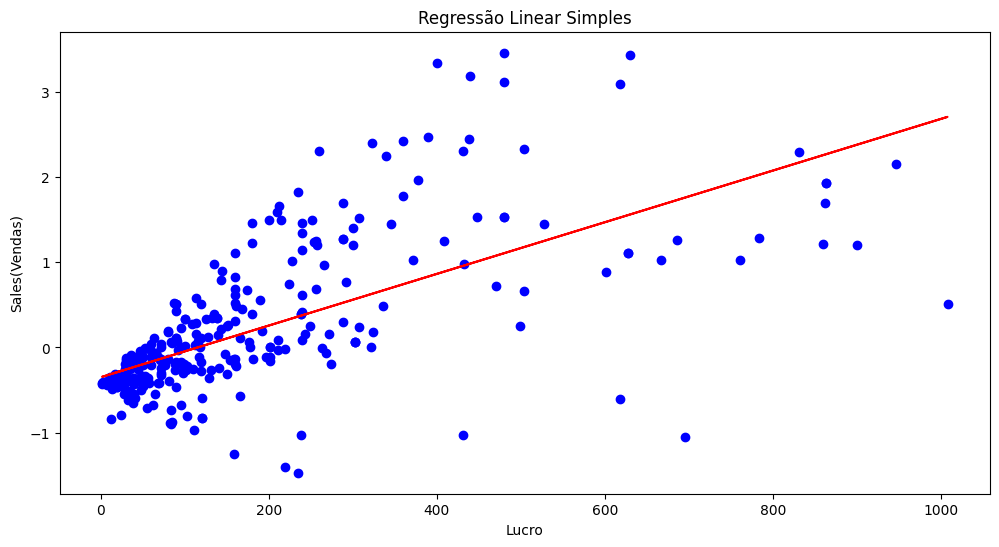

In [136]:
plt.figure(figsize=(12,6))
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Lucro")
plt.ylabel("Sales(Vendas)")
plt.title("Regressão Linear Simples")
plt.show()

In [137]:
# Avaliação do modelo
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

mse = mean_absolute_error(y_test, y_pred)
print(f"MSE: {mse}")

r2 = r2_score(y_test, y_pred)
print(f"R2: {r2}")

MAE: 0.435736250405206
MSE: 0.435736250405206
R2: 0.43010916521968134


## Modelo de Random Forest Regressor

In [138]:
from sklearn.ensemble import RandomForestRegressor

X2 = df[["Sales", "Label_State", "Quantity", "Label_Sub-Category", "Sales_por_Unidade"]]  
y2 = df[["Profit"]]  

# Divisão dos dados em treino e teste
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Criar o modelo de Random Forest
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)  # 100 árvores na floresta

# Treinar o modelo
rfr_model.fit(X_train2, y_train2)

# Fazer previsões no conjunto de teste
y_pred2 = rfr_model.predict(X_test2)

# Avaliar o modelo com métricas
mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r22 = r2_score(y_test2, y_pred2)

print(f"MAE: {mae2}")
print(f"MSE: {mse2}")
print(f"R²: {r22}")

C:\Users\Jhonathan Miguel\miniconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE: 14.519034054710534
MSE: 625.5734555897161
R²: 0.6077799775736139


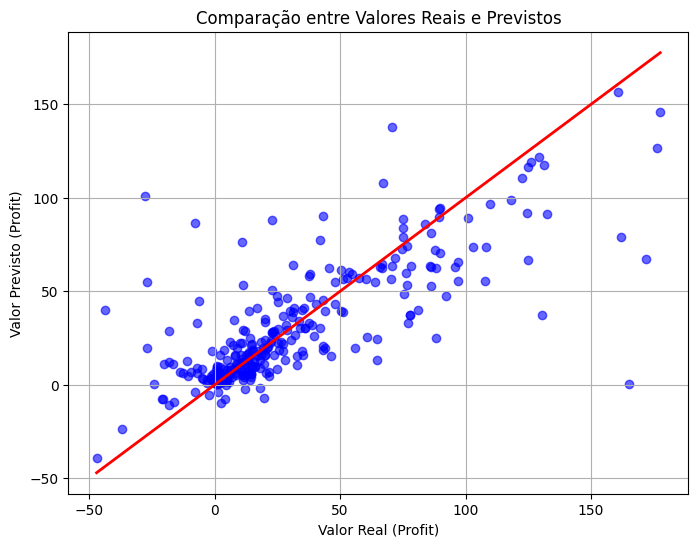

In [139]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test2, y_pred2, color="blue", alpha=0.6)
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], color="red", lw=2)  # Linha de 45º
plt.title("Comparação entre Valores Reais e Previstos")
plt.xlabel("Valor Real (Profit)")
plt.ylabel("Valor Previsto (Profit)")
plt.grid(True)
plt.show()

## Modelo de Rnadom Forest

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GridSearchCV

# usando Hiperparametros para achar a melhor classificação

param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [3, 5, 10, None],        
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4],        
    'bootstrap': [True, False]
}


X3 = df[["Sales", "Label_State", "Quantity", "Label_Sub-Category", "Sales_por_Unidade"]]  
y3 = df[["Profit_cat"]]

# Achatando o array em um vetor linha
y3 = np.ravel(y3)

# Divisão dos dados em treino e teste
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

# Criando o modelo de Random Forest
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")

# Configurando Hiperparametros
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                          cv=5)

grid_search.fit(X_train3, y_train3)

best_model = grid_search.best_estimator_
y_pred3 = best_model.predict(X_test3)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor score (validação):", grid_search.best_score_)

Melhores parâmetros: {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Melhor score (validação): 0.7565136476426799


In [141]:
# Exibir relatorio de classificação
print(classification_report(y_test3, y_pred3))

              precision    recall  f1-score   support

       Altas       0.77      0.82      0.80        90
      Baixas       0.80      0.77      0.78       108
      Medias       0.68      0.67      0.67       111

    accuracy                           0.75       309
   macro avg       0.75      0.75      0.75       309
weighted avg       0.75      0.75      0.75       309



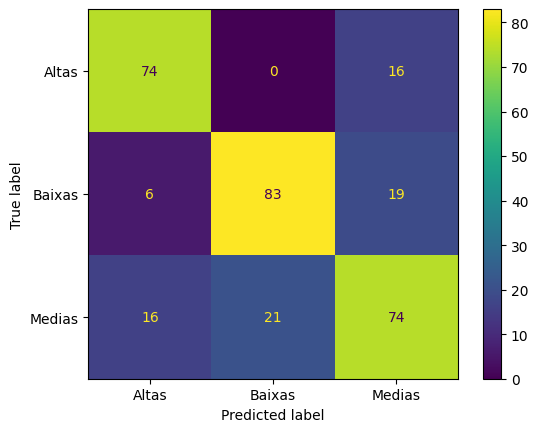

In [146]:
# Matrix de confução
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test3, y_pred3)
ConfusionMatrixDisplay.from_predictions(y_test3, y_pred3)